# Análise Demonstrativos Financeiros


A análise foi orientada para investidores, com foco em identificar empresas com bom desempenho financeiro para potenciais aportes de capital do seguimento de Agricultura (Açúcar, Álcool e Cana) como uso do R.

# Configuração do ambiente

Instalação do pacote **rpy2**, interface no Python para linguagem R

In [ ]:
!pip install rpy2

Importação do rpy2 e outras bibliotecas que facilitaão da conversão entre as linguagens

In [ ]:
import rpy2
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

from matplotlib import pyplot
import seaborn as sns

Para rodar o R de maneira interativa neste notebook, usamos comandos magic do IPython

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Instalamos o pacote no R.

In [ ]:
%R install.packages('GetDFPData2')

(as ‘lib’ is unspecified)







	‘/tmp/RtmprKGwul/downloaded_packages’



Através da interface com Python, importar pacote no R

In [ ]:
# importar DFPData2
r_base = importr('GetDFPData2')

Vamos começar a utilizar a biblioteca. Esta biblioteca contém diferentes base de dados, uma delas é base de informações gerais sobre as empresas.

In [ ]:
robjects.r('df_info <- get_info_companies(tempdir())')

CNPJ,DENOM_SOCIAL,DENOM_COMERC,...,EMAIL_RESP,CNPJ_AUDITOR,AUDITOR
'08.773.1...,'2W ECOBA...,'2W ECOBA...,...,'juridico...,'10.830.1...,'GRANT TH...
'11.396.6...,'3A COMPA...,'TRIPLO A...,,'juridico...,'60.525.7...,'MOORE ST...
'12.091.8...,'3R PETRO...,NA_character_,,'ri@brava...,'57.755.2...,'KPMG AUD...
'01.547.7...,'521 PART...,'521 PART...,,NA_character_,'13.859.9...,'BAKER TI...
...,...,...,,...,...,...
'71.320.9...,'ZANINI S...,'ZANINI',,NA_character_,'61.562.1...,'PRICEWAT...
'24.744.0...,'ZH OPERA...,'ZH OPERA...,,'renno@se...,'00.115.9...,'MS AUDIT...
'92.749.2...,'ZIVI SA ...,'ZIVI S/A',,'michael....,'61.562.1...,'PRICEWAT...
'74.533.7...,'ZOGBI LE...,'ZOGBI LE...,,'4000.iso...,'57.755.2...,'KPMG AUD...


Além de executar os comandos de R via rpy2, esta inferface permite transferencia de dados entre as linguagens. Vamos definir duas funções de conversão. Uma para converter uma dataframe do R em dataframe pandas do Python e outra para enviar um vetor do Python para o R.

In [ ]:
'''
converter_em_pd(df_r): converte dataframe do R para dataframe em python

input
- df_r: dataframe que queremos converter da linguagem R para dataframe pandas em python

output
- df_py: dataframe convertida

doc: https://rpy2.github.io/doc/v2.9.x/html/robjects_convert.html#conversion
'''

def converter_em_df_py(df_r):
  with localconverter(robjects.default_converter + pandas2ri.converter):
    df_py = robjects.conversion.rpy2py(df_r)
    return df_py

'''
converter_em_intVec_R(vec_py): converte vetor em python para vetor em R

input
- vec_py: vetor em Python que será convertido para vetor em R

output
- vec_r: vetor convertido

doc: https://rpy2.github.io/doc/v2.9.x/html/vector.html#creating-vectors
'''

def converter_em_intVec_R(vec_py):
  vec_r = robjects.vectors.IntVector(vec_py)
  return vec_r

Definida a função, podemos converter a dataframe que contém os dados gerais sobre as empresas.

In [ ]:
df_info = converter_em_df_py(robjects.r('get_info_companies(tempdir())'))
print(df_info.columns)

Index(['CNPJ', 'DENOM_SOCIAL', 'DENOM_COMERC', 'DT_REG', 'DT_CONST',
       'DT_CANCEL', 'MOTIVO_CANCEL', 'SIT_REG', 'DT_INI_SIT', 'CD_CVM',
       'SETOR_ATIV', 'TP_MERC', 'CATEG_REG', 'DT_INI_CATEG', 'SIT_EMISSOR',
       'DT_INI_SIT_EMISSOR', 'CONTROLE_ACIONARIO', 'TP_ENDER', 'LOGRADOURO',
       'COMPL', 'BAIRRO', 'MUN', 'UF', 'PAIS', 'CEP', 'DDD_TEL', 'TEL',
       'DDD_FAX', 'FAX', 'EMAIL', 'TP_RESP', 'RESP', 'DT_INI_RESP',
       'LOGRADOURO_RESP', 'COMPL_RESP', 'BAIRRO_RESP', 'MUN_RESP', 'UF_RESP',
       'PAIS_RESP', 'CEP_RESP', 'DDD_TEL_RESP', 'TEL_RESP', 'DDD_FAX_RESP',
       'FAX_RESP', 'EMAIL_RESP', 'CNPJ_AUDITOR', 'AUDITOR'],
      dtype='object')


# Desenvolvimento

In [ ]:
df_agro = df_info[(df_info['SETOR_ATIV'] == 'Agricultura (Açúcar, Álcool e Cana)') & (df_info['SIT_REG'] == 'ATIVO')]
df_agro

,CNPJ,DENOM_SOCIAL,DENOM_COMERC,DT_REG,DT_CONST,DT_CANCEL,MOTIVO_CANCEL,SIT_REG,DT_INI_SIT,CD_CVM,...,UF_RESP,PAIS_RESP,CEP_RESP,DDD_TEL_RESP,TEL_RESP,DDD_FAX_RESP,FAX_RESP,EMAIL_RESP,CNPJ_AUDITOR,AUDITOR
423,07.628.528/0001-59,BRASILAGRO CIA BRAS DE PROP AGRICOLAS,BRASILAGRO CIA BRAS DE PROP AGRICOLAS,13263.0,13049.0,NaN,None,ATIVO,13263.0,20036.0,...,SP,None,5402500.0,11,30355350.0,None,NaN,ri@brasil-agro.com,61.562.112/0001-20,PRICEWATERHOUSECOOPERS AUDITORES INDEPENDENTES...
571,08.322.396/0001-03,CERRADINHO BIOENERGIA S.A.,None,18982.0,13303.0,NaN,None,ATIVO,18982.0,26522.0,...,GO,None,75828000.0,17,33112990.0,None,NaN,ri@cerradinho.com.br,61.562.112/0001-20,PRICEWATERHOUSECOOPERS AUDITORES INDEPENDENTES...
927,50.746.577/0001-15,COSAN S.A.,COSAN SA INDUSTRIA E COMERCIO,13082.0,10988.0,NaN,None,ATIVO,13082.0,19836.0,...,None,None,4538132.0,11,38979797.0,None,NaN,dep.ri@cosan.com,54.276.936/0001-79,BDO RCS AUDITORES INDEPENDENTES - SOCIEDADE SI...
954,06.981.381/0001-13,CTC - CENTRO DE TECNOLOGIA CANAVIEIRA S.A.,CTC - CENTRO DE TECNOLOGIA CANAVIEIRA S.A.,17037.0,12640.0,NaN,None,ATIVO,17037.0,23981.0,...,None,None,13433899.0,19,34298199.0,None,NaN,ri@ctc.com.br,61.366.936/0001-25,ERNST & YOUNG AUDITORES INDEPENDENTES S/S LTDA.
1123,14.796.754/0001-04,ENGELHART CTP (BRASIL) S.A.,None,19920.0,15292.0,NaN,None,ATIVO,19920.0,27553.0,...,SP,None,4538133.0,11,33832000.0,None,NaN,ri-ectp@btgpactual.com,61.562.112/0001-20,PRICEWATERHOUSECOOPERS AUDITORES INDEPENDENTES...
1508,02.635.522/0001-95,JALLES MACHADO S.A.,JALLES MACHADO S.A,18662.0,3984.0,NaN,None,ATIVO,18662.0,25496.0,...,GO,None,76388899.0,62,33899000.0,None,NaN,ri@jallesmachado.com,57.755.217/0001-29,KPMG AUDITORES INDEPENDENTES LTDA.
1684,86.550.951/0001-50,MASSA FALIDA DE POMIFRUTAS S/A,POMIFRUTAS S/A,12780.0,-2618.0,NaN,None,ATIVO,12780.0,19658.0,...,SP,None,1532020.0,11,35281091.0,None,NaN,dicori@pomifrutas.com.br,13.026.685/0001-97,EVOLUÇÃO AUDITORES INDEPENDENTES S/S ILIMITADA
1847,51.128.999/0001-90,NUTRIPLANT INDUSTRIA E COMÉRCIO S/A,NUTRIPLANT,13920.0,3287.0,NaN,None,ATIVO,13920.0,21334.0,...,SP,None,6415110.0,11,41617600.0,None,NaN,ri@nutriplant.com.br,23.894.193/0001-77,HOLDER AUDITORES INDEPENDENTES S/S - EPP
2034,08.070.508/0001-78,RAÍZEN ENERGIA S.A.,None,15999.0,11277.0,NaN,None,ATIVO,15999.0,23230.0,...,SP,None,4538132.0,11,45171545.0,None,NaN,depart.ri@raizen.com,61.366.936/0001-25,ERNST & YOUNG AUDITORES INDEPENDENTES S/S LTDA.
2187,51.466.860/0001-56,SÃO MARTINHO SA,SÃO MARTINHO SA,13551.0,-11859.0,NaN,None,ATIVO,13551.0,20516.0,...,SP,None,4575060.0,11,21054100.0,None,NaN,ri@saomartinho.com.br,57.755.217/0001-29,KPMG AUDITORES INDEPENDENTES LTDA.


In [ ]:
cd_cvm_ativos_agro = [int(code) for code in list(df_agro['CD_CVM'])]
cd_cvm_ativos_agro

[20036,
 26522,
 19836,
 23981,
 27553,
 25496,
 19658,
 21334,
 23230,
 20516,
 20745,
 26000,
 25950,
 25763]

In [ ]:
robjects.r('df_dre <- get_dfp_data(companies_cvm_codes = c(20036, 26522, 19836,23981,27553,25496,19658,21334, 23230, 20516, 20745,26000,25950,25763), \
                      use_memoise = FALSE,\
                      clean_data = TRUE, \
                      cache_folder = tempdir(),\
                      type_docs = c("DRE", "BPA", "BPP"), \
                      type_format = "con",\
                      first_year = 2017, \
                      last_year = 2023)')

DF Consolidado - Balanço Patrimonial Ativo,[RTYPES.VECSXP]
DF Consolidado - Balanço Patrimonial Passivo,[RTYPES.VECSXP]
DF Consolidado - Demonstração do Resultado,[RTYPES.VECSXP]


In [ ]:
robjects.r('print(df_dre)')

$`DF Consolidado - Balanço Patrimonial Ativo`
# A tibble: 4,700 × 16
   CNPJ_CIA         CD_CVM DT_REFER   DT_INI_EXERC DT_FIM_EXERC DENOM_CIA VERSAO
   <chr>             <dbl> <date>     <date>       <date>       <chr>      <dbl>
 1 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
 2 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
 3 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
 4 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
 5 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
 6 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
 7 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
 8 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
 9 07.628.528/0001…  20036 2017-06-30 NA           2017-06-30   BRASILAG…      1
10 07.628.528/0001…  20036 2017-06-30 NA

DF Consolidado - Balanço Patrimonial Ativo,[RTYPES.VECSXP]
DF Consolidado - Balanço Patrimonial Passivo,[RTYPES.VECSXP]
DF Consolidado - Demonstração do Resultado,[RTYPES.VECSXP]


In [ ]:
# concatenar ListVector de tibbles e transformar em uma df
robjects.r('df_my <- as.data.frame(do.call(rbind,df_dre))')
robjects.r('print(dim(df_my))')

# converter colunas tipo Date em String
print("-> Antes da conversão")
robjects.r('str(df_my)') # mostrar as colunas e os respectivos tipos
robjects.r('df_my[,3] <- strftime(df_my[,3], format = "%Y", tz = "")')
robjects.r('df_my[,4] <- strftime(df_my[,4], format = "%Y", tz = "")')
robjects.r('df_my[,5] <- strftime(df_my[,5], format = "%Y", tz = "")')
print("-> Após conversão")
robjects.r('str(df_my)') # mostrar as colunas e os respectivos tipos após conversão

[1] 14994    16
-> Antes da conversão
'data.frame':	14994 obs. of  16 variables:
 $ CNPJ_CIA    : chr  "07.628.528/0001-59" "07.628.528/0001-59" "07.628.528/0001-59" "07.628.528/0001-59" ...
 $ CD_CVM      : num  20036 20036 20036 20036 20036 ...
 $ DT_REFER    : Date, format: "2017-06-30" "2017-06-30" ...
 $ DT_INI_EXERC: Date, format: NA NA ...
 $ DT_FIM_EXERC: Date, format: "2017-06-30" "2017-06-30" ...
 $ DENOM_CIA   : chr  "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS" "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS" "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS" "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS" ...
 $ VERSAO      : num  1 1 1 1 1 1 1 1 1 1 ...
 $ GRUPO_DFP   : chr  "DF Consolidado - Balanço Patrimonial Ativo" "DF Consolidado - Balanço Patrimonial Ativo" "DF Consolidado - Balanço Patrimonial Ativo" "DF Consolidado - Balanço Patrimonial Ativo" ...
 $ MOEDA       : chr  "REAL" "REAL" "REAL" "REAL" ...
 $ ESCALA_MOEDA: chr  "MIL" "MIL" "MIL" "MIL" ...
 $ ORDEM_EXERC : chr  "ÚLTIMO" "ÚLTIMO" 

<rpy2.rinterface_lib.sexp.NULLType object at 0x7a01a70b9480> [RTYPES.NILSXP]

In [ ]:
#aqui o programa faz uma linha para cada informação
df_raw = converter_em_df_py(robjects.r('as.data.frame(df_my)'))
df_raw

,CNPJ_CIA,CD_CVM,DT_REFER,DT_INI_EXERC,DT_FIM_EXERC,DENOM_CIA,VERSAO,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,COLUNA_DF,source_file
1,07.628.528/0001-59,20036.0,2017,None,2017,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,1.0,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,1,Ativo Total,883293.00000,-2147483648,dfp_cia_aberta_BPA_con_2017.csv
2,07.628.528/0001-59,20036.0,2017,None,2017,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,1.0,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,1.01,Ativo Circulante,171102.00000,-2147483648,dfp_cia_aberta_BPA_con_2017.csv
3,07.628.528/0001-59,20036.0,2017,None,2017,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,1.0,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,1.01.01,Caixa e Equivalentes de Caixa,43798.00000,-2147483648,dfp_cia_aberta_BPA_con_2017.csv
4,07.628.528/0001-59,20036.0,2017,None,2017,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,1.0,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,1.01.02,Aplicações Financeiras,6972.00000,-2147483648,dfp_cia_aberta_BPA_con_2017.csv
5,07.628.528/0001-59,20036.0,2017,None,2017,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,1.0,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,1.01.02.01,Aplicações Financeiras Avaliadas a Valor Justo,6972.00000,-2147483648,dfp_cia_aberta_BPA_con_2017.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14990,94.813.102/0001-70,25950.0,2023,2023,2023,TRÊS TENTOS AGROINDUSTRIAL S/A,1.0,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,3.99,Lucro por Ação - (Reais / Ação),0.00000,-2147483648,dfp_cia_aberta_DRE_con_2023.csv
14991,94.813.102/0001-70,25950.0,2023,2023,2023,TRÊS TENTOS AGROINDUSTRIAL S/A,1.0,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,3.99.01,Lucro Básico por Ação,0.00000,-2147483648,dfp_cia_aberta_DRE_con_2023.csv
14992,94.813.102/0001-70,25950.0,2023,2023,2023,TRÊS TENTOS AGROINDUSTRIAL S/A,1.0,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,3.99.01.01,ON,1.15216,-2147483648,dfp_cia_aberta_DRE_con_2023.csv
14993,94.813.102/0001-70,25950.0,2023,2023,2023,TRÊS TENTOS AGROINDUSTRIAL S/A,1.0,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,3.99.02,Lucro Diluído por Ação,0.00000,-2147483648,dfp_cia_aberta_DRE_con_2023.csv


In [ ]:
df_analysis = df_raw.pivot_table(index=['DENOM_CIA','DT_FIM_EXERC'], columns='DS_CONTA', values='VL_CONTA')
df_analysis = df_analysis.reset_index() # transforma índice hierárquico em colunas
df_analysis

DS_CONTA,DENOM_CIA,DT_FIM_EXERC,Adiantamento a Fornecedores,Adiantamento a fornecedores,Adiantamento de Clientes,Adiantamento de clientes,Adiantamento para Futuro Aumento de Capital,Adiantamentos,Adiantamentos a Fornecedores,Adiantamentos a fornecedores,...,"Variação cambial, líquida",Variação do Vaor Justo dos Ativos Biológicos e Produtos Agrícolas,Variação do valor justo de ativos biológicos,Variação do valor justo dos ativos biológicos,Variação no valor justo de ativo biológico,"Variações cambiais, líquida","Variações cambiais, líquidas",Variações monetárias e cambiais líquidas,Venda ativo imobilizado,Ágio na Emissão de Ações
0,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2017,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2018,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2019,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2020,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-33566.0
4,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2021,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,VITTIA S.A.,2019,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
67,VITTIA S.A.,2020,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
68,VITTIA S.A.,2021,NaN,NaN,NaN,16449.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
69,VITTIA S.A.,2022,NaN,NaN,NaN,13154.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [ ]:
# liquidez a seco
df_analysis['Liquidez'] = (df_analysis['Ativo Circulante'] - df_analysis['Estoques'])/df_analysis['Passivo Circulante']
# giro
df_analysis['Giro'] = df_analysis['Receita de Venda de Bens e/ou Serviços']/df_analysis['Ativo Total']
# Retorno sobre os ativos
df_analysis['ROA'] = df_analysis['Resultado Antes do Resultado Financeiro e dos Tributos']/df_analysis['Ativo Total']
# Retorno sobre o patrimonio liquido
df_analysis['ROE'] = df_analysis['Lucro/Prejuízo Consolidado do Período']/df_analysis['Patrimônio Líquido Consolidado']
# Margem operacional
df_analysis['Mg_op'] = df_analysis['Resultado Antes do Resultado Financeiro e dos Tributos']/df_analysis['Receita de Venda de Bens e/ou Serviços']
# Margem liquida
df_analysis['Mg_liq'] = df_analysis['Lucro/Prejuízo Consolidado do Período']/df_analysis['Receita de Venda de Bens e/ou Serviços']


df_analysis[['DENOM_CIA','DT_FIM_EXERC','Liquidez','Giro','ROA','ROE','Mg_op','Mg_liq']]

DS_CONTA,DENOM_CIA,DT_FIM_EXERC,Liquidez,Giro,ROA,ROE,Mg_op,Mg_liq
0,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2017,0.874739,0.208581,-0.000209,0.040916,-0.001004,0.148232
1,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2018,1.661152,0.325586,0.136329,0.167144,0.418717,0.328953
2,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2019,1.731076,0.409100,0.137650,0.201104,0.336471,0.318831
3,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2020,1.432358,0.344951,0.080359,0.106595,0.232959,0.169531
4,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2021,2.462266,0.356055,0.114960,0.145536,0.322871,0.260223
...,...,...,...,...,...,...,...,...
66,VITTIA S.A.,2019,1.719917,0.939660,0.144612,0.266573,0.153898,0.134537
67,VITTIA S.A.,2020,1.506386,0.854841,0.162034,0.295228,0.189548,0.161942
68,VITTIA S.A.,2021,1.722264,0.920944,0.168886,0.221756,0.183383,0.138321
69,VITTIA S.A.,2022,1.905769,0.888072,0.189123,0.254113,0.212959,0.173269


In [ ]:
vec_r = converter_em_intVec_R(cd_cvm_ativos_agro)
robjects.globalenv['cd_cvm_ativos_agro'] = vec_r
robjects.r('df_dre <- get_dfp_data(companies_cvm_codes = cd_cvm_ativos_agro,\
                      use_memoise = FALSE,\
                      clean_data = TRUE,\
                      cache_folder = tempdir(),\
                      type_docs = c("DRE","BPA","BPP"), \
                      type_format = "con",\
                      first_year = 2017, \
                      last_year = 2023)')

# concatenar ListVector de tibbles e transformar em uma df
robjects.r('df_my <- as.data.frame(do.call(rbind,df_dre))')
robjects.r('print(dim(df_my))')

# converter colunas tipo Date em String
print("-> Antes da conversão")
robjects.r('str(df_my)') # mostrar as colunas e os respectivos tipos
robjects.r('df_my[,3] <- strftime(df_my[,3], format = "%Y", tz = "")')
robjects.r('df_my[,4] <- strftime(df_my[,4], format = "%Y", tz = "")')
robjects.r('df_my[,5] <- strftime(df_my[,5], format = "%Y", tz = "")')
print("-> Após conversão")
df_raw = converter_em_df_py(robjects.r('as.data.frame(df_my)'))
df_analysis = df_raw.pivot_table(index=['DENOM_CIA','DT_FIM_EXERC'], columns='DS_CONTA', values='VL_CONTA')
df_analysis = df_analysis.reset_index() # transforma índice hierárquico em colunas

[1] 14994    16
-> Antes da conversão
'data.frame':	14994 obs. of  16 variables:
 $ CNPJ_CIA    : chr  "07.628.528/0001-59" "07.628.528/0001-59" "07.628.528/0001-59" "07.628.528/0001-59" ...
 $ CD_CVM      : num  20036 20036 20036 20036 20036 ...
 $ DT_REFER    : Date, format: "2017-06-30" "2017-06-30" ...
 $ DT_INI_EXERC: Date, format: NA NA ...
 $ DT_FIM_EXERC: Date, format: "2017-06-30" "2017-06-30" ...
 $ DENOM_CIA   : chr  "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS" "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS" "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS" "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS" ...
 $ VERSAO      : num  1 1 1 1 1 1 1 1 1 1 ...
 $ GRUPO_DFP   : chr  "DF Consolidado - Balanço Patrimonial Ativo" "DF Consolidado - Balanço Patrimonial Ativo" "DF Consolidado - Balanço Patrimonial Ativo" "DF Consolidado - Balanço Patrimonial Ativo" ...
 $ MOEDA       : chr  "REAL" "REAL" "REAL" "REAL" ...
 $ ESCALA_MOEDA: chr  "MIL" "MIL" "MIL" "MIL" ...
 $ ORDEM_EXERC : chr  "ÚLTIMO" "ÚLTIMO" 

In [ ]:
# liquidez a seco
df_analysis['Liquidez'] = (df_analysis['Ativo Circulante'] - df_analysis['Estoques'])/df_analysis['Passivo Circulante']
# giro
df_analysis['Giro'] = df_analysis['Receita de Venda de Bens e/ou Serviços']/df_analysis['Ativo Total']
# Retorno sobre os ativos
df_analysis['ROA'] = df_analysis['Resultado Antes do Resultado Financeiro e dos Tributos']/df_analysis['Ativo Total']
# Retorno sobre o patrimonio liquido
df_analysis['ROE'] = df_analysis['Lucro/Prejuízo Consolidado do Período']/df_analysis['Patrimônio Líquido Consolidado']
# Margem operacional
df_analysis['Mg_op'] = df_analysis['Resultado Antes do Resultado Financeiro e dos Tributos']/df_analysis['Receita de Venda de Bens e/ou Serviços']
# Margem liquida
df_analysis['Mg_liq'] = df_analysis['Lucro/Prejuízo Consolidado do Período']/df_analysis['Receita de Venda de Bens e/ou Serviços']


df_analysis[['DENOM_CIA','DT_FIM_EXERC','Liquidez','Giro','ROA','ROE','Mg_op','Mg_liq']]

DS_CONTA,DENOM_CIA,DT_FIM_EXERC,Liquidez,Giro,ROA,ROE,Mg_op,Mg_liq
0,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2017,0.874739,0.208581,-0.000209,0.040916,-0.001004,0.148232
1,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2018,1.661152,0.325586,0.136329,0.167144,0.418717,0.328953
2,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2019,1.731076,0.409100,0.137650,0.201104,0.336471,0.318831
3,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2020,1.432358,0.344951,0.080359,0.106595,0.232959,0.169531
4,BRASILAGRO - CIA BRAS DE PROP AGRICOLAS,2021,2.462266,0.356055,0.114960,0.145536,0.322871,0.260223
...,...,...,...,...,...,...,...,...
66,VITTIA S.A.,2019,1.719917,0.939660,0.144612,0.266573,0.153898,0.134537
67,VITTIA S.A.,2020,1.506386,0.854841,0.162034,0.295228,0.189548,0.161942
68,VITTIA S.A.,2021,1.722264,0.920944,0.168886,0.221756,0.183383,0.138321
69,VITTIA S.A.,2022,1.905769,0.888072,0.189123,0.254113,0.212959,0.173269


<ipython-input-69-efc5ea4bcee8>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analysis_2023, x="DENOM_CIA", y="Liquidez", order = df_analysis_2023.sort_values('Liquidez').DENOM_CIA, palette='viridis')


<Axes: xlabel='DENOM_CIA', ylabel='Liquidez'>

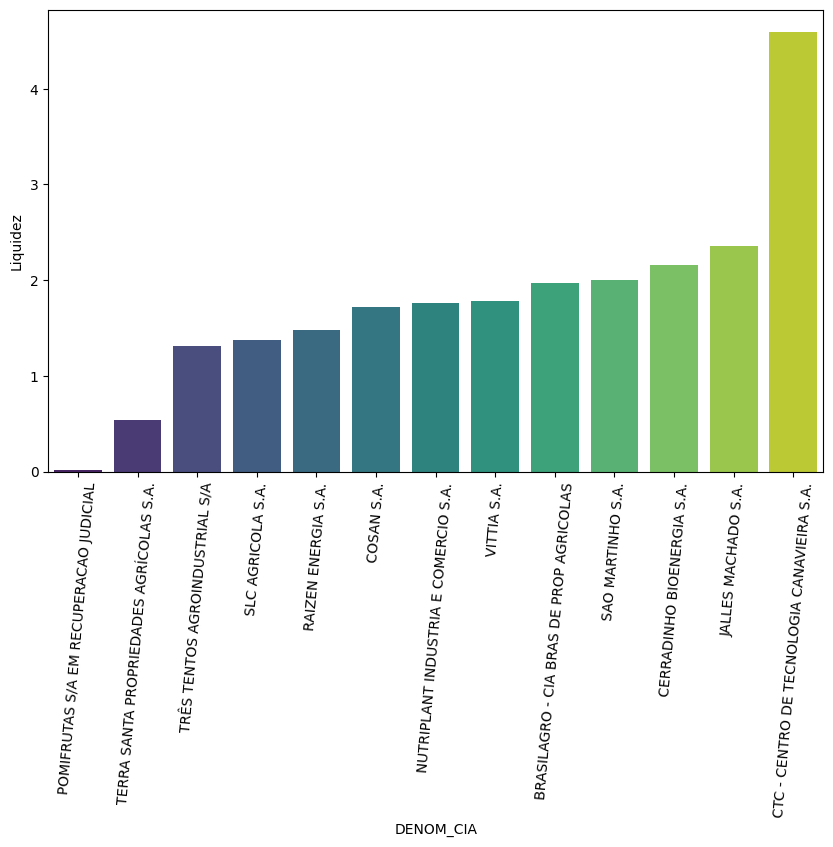

In [ ]:
#Liquidez
# config. dim da figura
fig, ax = pyplot.subplots(figsize=(10, 6))
ax.tick_params(axis='x', rotation=85)
# plotar para 2023
df_analysis_2023 = df_analysis[df_analysis['DT_FIM_EXERC'] == '2023']
sns.barplot(data=df_analysis_2023, x="DENOM_CIA", y="Liquidez", order = df_analysis_2023.sort_values('Liquidez').DENOM_CIA, palette='viridis')

<ipython-input-58-4911cc183b53>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analysis_2023, x="DENOM_CIA", y="Mg_op", order = df_analysis_2023.sort_values('Mg_op').DENOM_CIA, palette='viridis')


<Axes: xlabel='DENOM_CIA', ylabel='Mg_op'>

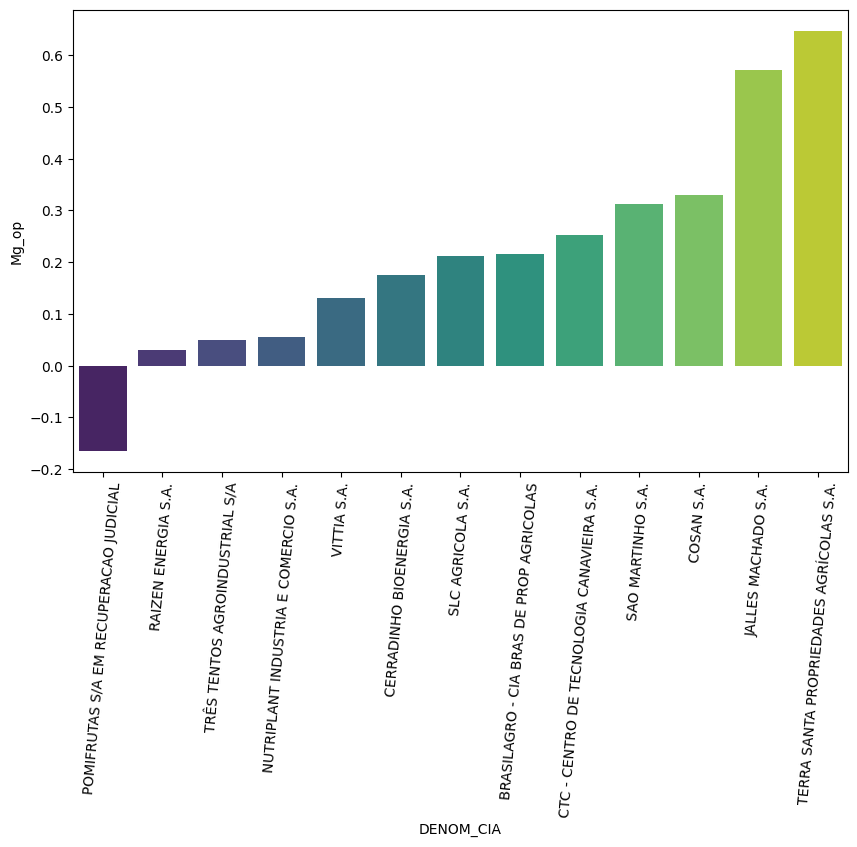

In [ ]:
# config. dim da figura
fig, ax = pyplot.subplots(figsize=(10, 6))
ax.tick_params(axis='x', rotation=85)
# plotar para 2023
df_analysis_2023 = df_analysis[df_analysis['DT_FIM_EXERC'] == '2023']
sns.barplot(data=df_analysis_2023, x="DENOM_CIA", y="Mg_op", order = df_analysis_2023.sort_values('Mg_op').DENOM_CIA, palette='viridis')

<ipython-input-59-5b1c164b8ec5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analysis_2023, x="DENOM_CIA", y="Mg_liq", order = df_analysis_2023.sort_values('Mg_liq').DENOM_CIA, palette='viridis')


<Axes: xlabel='DENOM_CIA', ylabel='Mg_liq'>

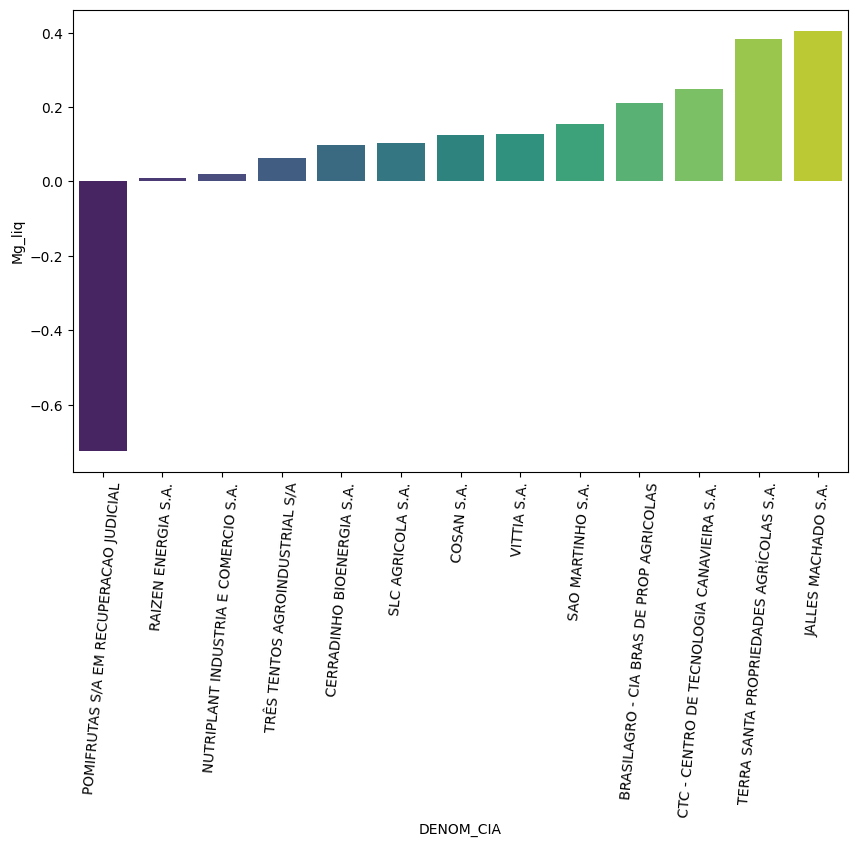

In [ ]:
# config. dim da figura
fig, ax = pyplot.subplots(figsize=(10, 6))
ax.tick_params(axis='x', rotation=85)
# plotar para 2023
df_analysis_2023 = df_analysis[df_analysis['DT_FIM_EXERC'] == '2023']
sns.barplot(data=df_analysis_2023, x="DENOM_CIA", y="Mg_liq", order = df_analysis_2023.sort_values('Mg_liq').DENOM_CIA, palette='viridis')

<Axes: xlabel='DT_FIM_EXERC', ylabel='Liquidez'>

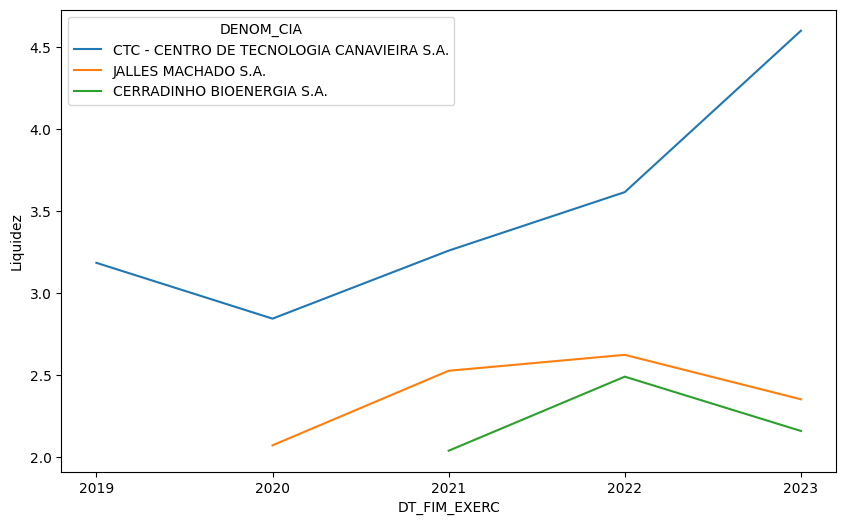

In [ ]:
#Comparando algumas empresas - Liquidez

# filtrar base
df_analysis_filtered = df_analysis[(df_analysis['DENOM_CIA'] == 'CTC - CENTRO DE TECNOLOGIA CANAVIEIRA S.A.') |
                                   (df_analysis['DENOM_CIA'] == 'JALLES MACHADO S.A.') |
                                   (df_analysis['DENOM_CIA'] == 'CERRADINHO BIOENERGIA S.A.') ]

# Ordenar por data
df_analysis_filtered = df_analysis_filtered.sort_values(by='DT_FIM_EXERC')
# config. dim da figura
fig, ax = pyplot.subplots(figsize=(10, 6))
sns.lineplot(data=df_analysis_filtered, x="DT_FIM_EXERC", y="Liquidez", hue="DENOM_CIA")

<Axes: xlabel='DT_FIM_EXERC', ylabel='Mg_op'>

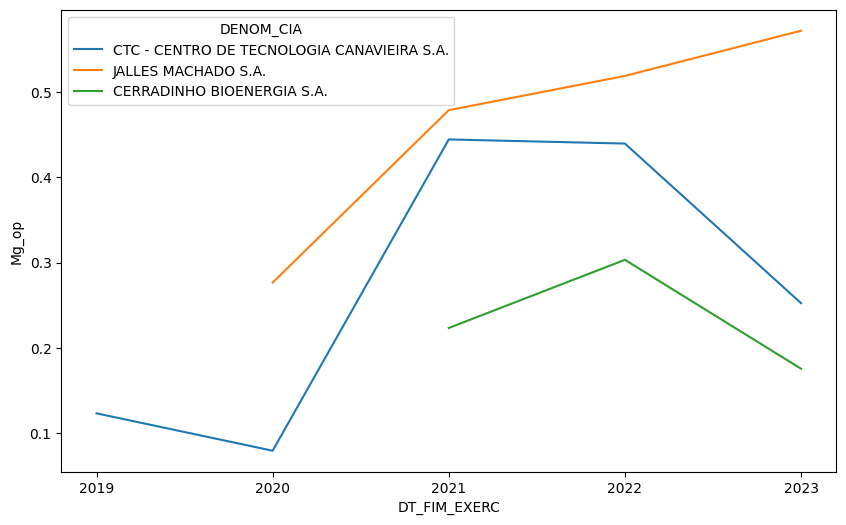

In [ ]:
#Comparando algumas empresas - Margem Operacional

# filtrar base
df_analysis_filtered = df_analysis[(df_analysis['DENOM_CIA'] == 'CTC - CENTRO DE TECNOLOGIA CANAVIEIRA S.A.') |
                                   (df_analysis['DENOM_CIA'] == 'JALLES MACHADO S.A.') |
                                   (df_analysis['DENOM_CIA'] == 'CERRADINHO BIOENERGIA S.A.') ]

# Ordenar por data
df_analysis_filtered = df_analysis_filtered.sort_values(by='DT_FIM_EXERC')


# config. dim da figura
fig, ax = pyplot.subplots(figsize=(10, 6))
sns.lineplot(data=df_analysis_filtered, x="DT_FIM_EXERC", y="Mg_op", hue="DENOM_CIA")

<Axes: xlabel='DT_FIM_EXERC', ylabel='Mg_liq'>

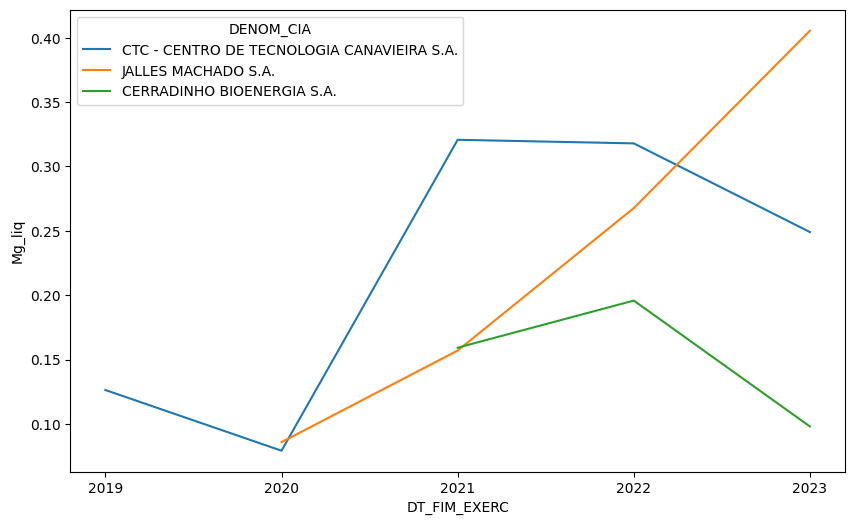

In [ ]:
#Comparando algumas empresas - Margem Liquida

# filtrar base
df_analysis_filtered = df_analysis[(df_analysis['DENOM_CIA'] == 'CTC - CENTRO DE TECNOLOGIA CANAVIEIRA S.A.') |
                                   (df_analysis['DENOM_CIA'] == 'JALLES MACHADO S.A.') |
                                   (df_analysis['DENOM_CIA'] == 'CERRADINHO BIOENERGIA S.A.') ]

# Ordenar por data
df_analysis_filtered = df_analysis_filtered.sort_values(by='DT_FIM_EXERC')


# config. dim da figura
fig, ax = pyplot.subplots(figsize=(10, 6))
sns.lineplot(data=df_analysis_filtered, x="DT_FIM_EXERC", y="Mg_liq", hue="DENOM_CIA")

<ipython-input-78-9737aa191204>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ranking, x="ROE", y="DENOM_CIA", palette="coolwarm")


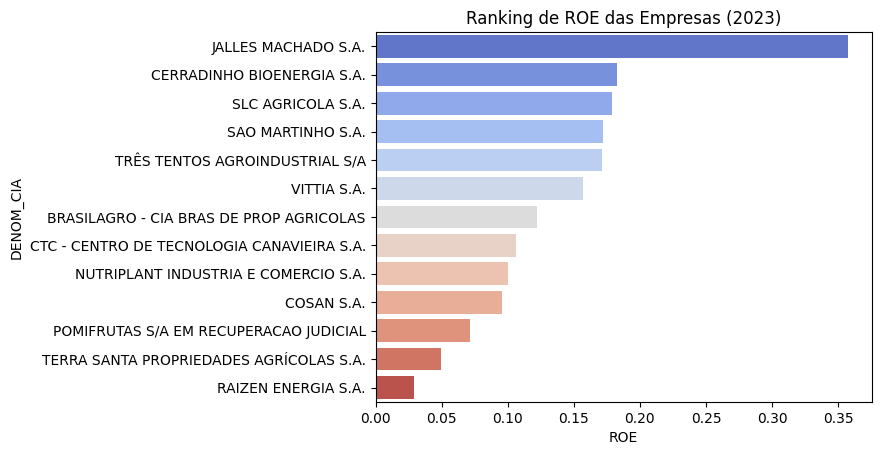

In [ ]:
# Ranking por ROE
df_ranking = df_analysis[df_analysis['DT_FIM_EXERC'] == '2023'].sort_values('ROE', ascending=False)
sns.barplot(data=df_ranking, x="ROE", y="DENOM_CIA", palette="coolwarm")
pyplot.title("Ranking de ROE das Empresas (2023)")
pyplot.show()


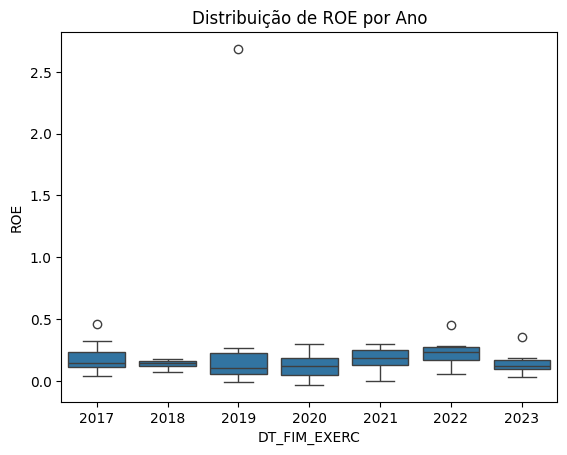

In [ ]:
sns.boxplot(data=df_analysis, x="DT_FIM_EXERC", y="ROE")
pyplot.title("Distribuição de ROE por Ano")
pyplot.show()


<ipython-input-64-07b974180c87>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ranking, x="ROA", y="DENOM_CIA", palette="coolwarm")


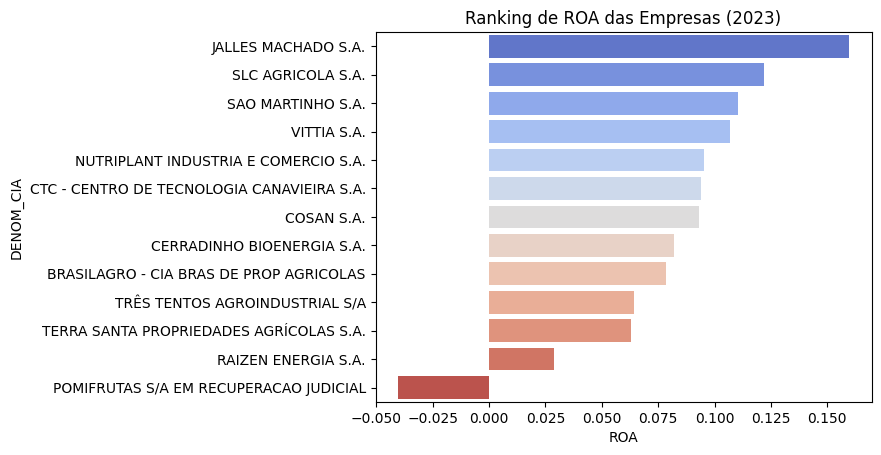

In [ ]:
# Ranking por ROA
df_ranking = df_analysis[df_analysis['DT_FIM_EXERC'] == '2023'].sort_values('ROA', ascending=False)
sns.barplot(data=df_ranking, x="ROA", y="DENOM_CIA", palette="coolwarm")
pyplot.title("Ranking de ROA das Empresas (2023)")
pyplot.show()


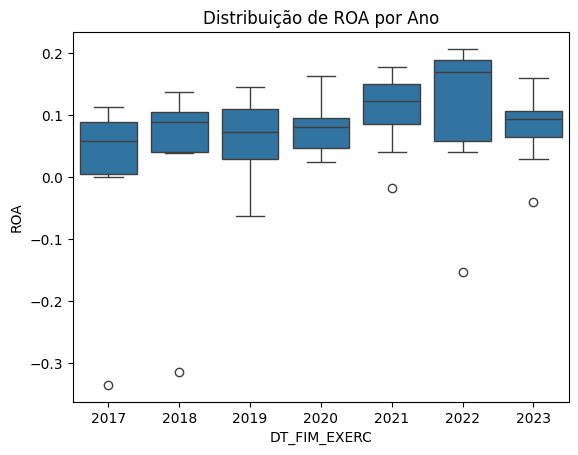

In [ ]:
sns.boxplot(data=df_analysis, x="DT_FIM_EXERC", y="ROA")
pyplot.title("Distribuição de ROA por Ano")
pyplot.show()

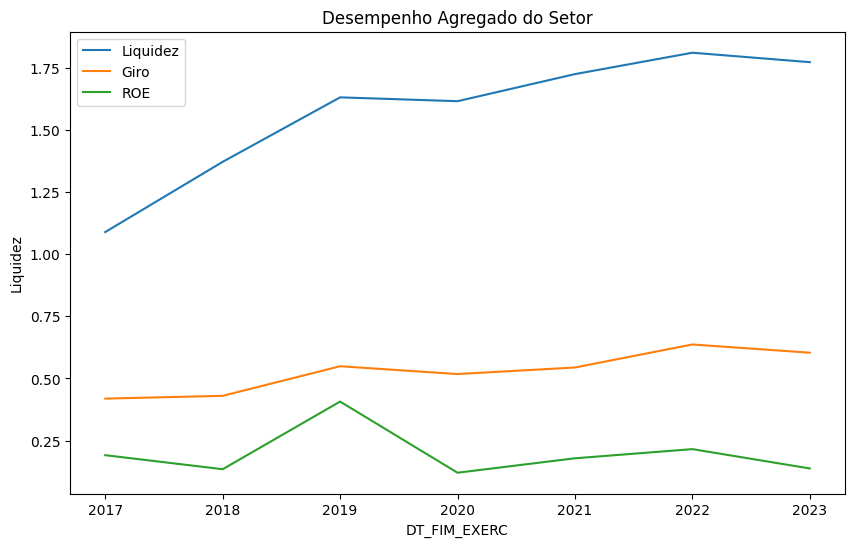

In [ ]:
#Análise Geral do Setor

df_sector = df_analysis.groupby('DT_FIM_EXERC')[['Liquidez', 'Giro', 'ROE']].mean().reset_index()
fig, ax = pyplot.subplots(figsize=(10, 6))
sns.lineplot(data=df_sector, x="DT_FIM_EXERC", y="Liquidez", label="Liquidez")
sns.lineplot(data=df_sector, x="DT_FIM_EXERC", y="Giro", label="Giro")
sns.lineplot(data=df_sector, x="DT_FIM_EXERC", y="ROE", label="ROE")
pyplot.title("Desempenho Agregado do Setor")
pyplot.legend()
pyplot.show()


# Conclusões

**Empresas acima da média: <br>**
Jalles Machado S.A.: Destaque em liquidez e margens operacionais.<br>
Cerradinho Bioenergia S.A.: Apresenta um ROA robusto e boa eficiência operacional.<br>
Empresas abaixo da média:<br>
CTC - Centro de Tecnologia Canavieira S.A.: Indicadores de margem líquida abaixo do esperado, sugerindo menor eficiência.<br>
Pomifrutas S/A Em recuperação judicial: Vários indicadores em déficit, liquidez zerada, margens operacional e líquida negativas.



**Recomendações para Investidores**<br>
Aportar capital em empresas líderes (Jalles Machado, Cerradinho Bioenergia) para maximizar retornos.<br>
Monitorar empresas com desempenho abaixo da média, como CTC, para possíveis melhorias ou reestruturações antes de investir.<br>
Priorizar indicadores de eficiência e margem para decisões estratégicas no setor.

